# Metric Learning with UMAP and Classifiers

The following code snippets should demonstrate the principle of metric learning that is utilized throughout the BHMC sampling algorithm.Using the labels obtained from for example K-Means clustering a KNN or SVM classifier is trained on the UMAP embedding of the data. This allows us to learn a distance metric that is more meaningful for our specific dataset which can be used for classification of new data points



## Example 1 Water Dimer

In [41]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [42]:
# SOAP feature config
from dscribe.descriptors import SOAP
r_cut = 6
n_max = 12
l_max = 8
sigma = 0.5
rbf = "gto"
average = "inner"

In [43]:
h2o_2_1 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_1.xyz")
h2o_2_2 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_2.xyz")
h2o_2_3 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_3.xyz")
h2o_2_4 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_4.xyz")
h2o_2_5 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_5.xyz")

# Find covalent bonds using a simple distance-based criterion
def find_bonds(atoms, cutoff=1.2):
    positions = atoms.get_positions()
    symbols = atoms.get_chemical_symbols()
    bonds = []
    for i in range(len(atoms)):
        for j in range(i + 1, len(atoms)):
            distance = np.linalg.norm(positions[i] - positions[j])
            if distance < cutoff:
                bonds.append((i, j))
    return bonds

print(find_bonds(h2o_2_1))
print(find_bonds(h2o_2_2))
print(find_bonds(h2o_2_3))
print(find_bonds(h2o_2_4))
print(find_bonds(h2o_2_5))

[(0, 1), (0, 2), (3, 4), (3, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]


In [44]:
submol_indices_1 = [[0,1,2], [3,4,5]]
submol_indices_2 = [[0,2,3],[1,4,5]]
submol_indices_3 = [[0,2,3],[1,4,5]]
submol_indices_4 = [[0,2,3],[1,4,5]]
submol_indices_5 = [[0,2,3],[1,4,5]]

In [45]:
soap = SOAP(
    species=["H", "O"],
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf=rbf,
    average=average,
)

In [46]:
# Original structures and their labels
original_structures = [h2o_2_1, h2o_2_2, h2o_2_3, h2o_2_4, h2o_2_5]
submol_indices = [submol_indices_1, submol_indices_2, submol_indices_3, submol_indices_4, submol_indices_5]
structure_labels = ["H$_2$O Conf1", "H$_2$O Conf2", "H$_2$O Conf3", "H$_2$O Conf4", "H$_2$O Conf5"]

def generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=0.05):
    perturbed_structures = []
    perturbed_labels = []

    for struct_idx, (original_struct, submol_idx, label) in enumerate(zip(original_structures, submol_indices, structure_labels)):
        for pert in range(n_perturbations):
            # Create a copy of the structure
            perturbed_struct = original_struct.copy()
            
            # Randomly choose which submolecule to perturb
            submol_to_perturb = np.random.choice([0, 1])
            indices_to_perturb = submol_idx[submol_to_perturb]
            
            # Generate random perturbations
            positions = perturbed_struct.get_positions()
            # Sample random vector from normal distribution and apply the perturbation scale
            random_displacement = np.random.randn(len(indices_to_perturb), 3) * perturbation_scale
            
            # Apply perturbations to selected submolecule
            # This preserves the internal structure of the submolecule while introducing noise to the overall structure
            for i, atom_idx in enumerate(indices_to_perturb):
                positions[atom_idx] += random_displacement[i]
            
            perturbed_struct.set_positions(positions)
            perturbed_structures.append(perturbed_struct)
            perturbed_labels.append(label)

    # Generate SOAP features for all perturbed structures
    perturbed_feature_matrix = soap.create(perturbed_structures)
    
    return perturbed_structures, perturbed_labels, perturbed_feature_matrix

We first populate our minima. For this we generate structures with a small pertubation level and train our classifier on this well separated data.

In [ ]:
perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
    original_structures, submol_indices, structure_labels, n_perturbations=100, perturbation_scale=0.01
)


In [ ]:
# Get the UMAP embedding and the K-MEANS
from umap import UMAP
from sklearn.cluster import KMeans
umap_model = UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)


As we can see above UMAP is again able to seperate and cluster the different configurations at this low pertubaton level. We now try the metric learning pipeline. For this we first train a UMAP embedding and generate test data which we want to fit in this embedding. For the test data we just use pertubations with a higher level

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.local/lib/python3.9/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


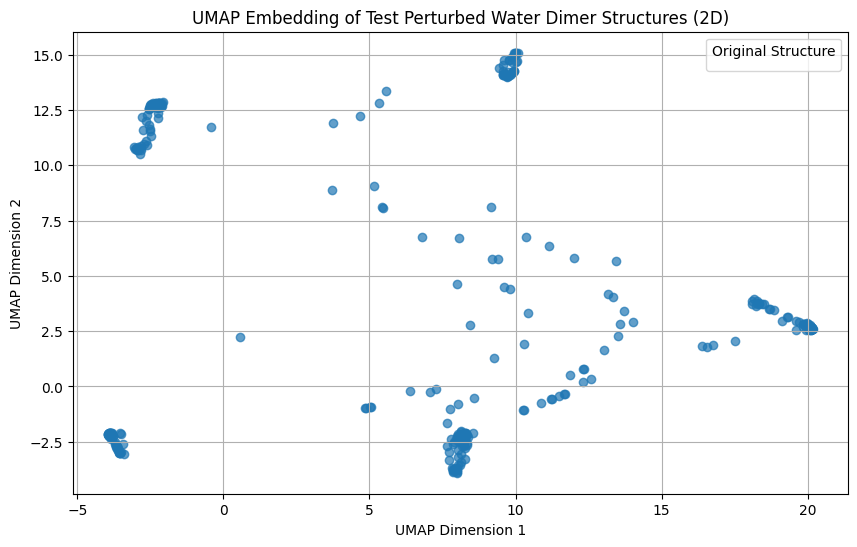

In [49]:
test_structures, test_labels, test_feature_matrix = generate_perturbed_structures_and_features(
    original_structures, submol_indices, structure_labels, n_perturbations=100, perturbation_scale=0.5
)
# Train the umap embedding
# Use the initial perturbed structures and the cluster labels from K-Means
mapper = umap.UMAP(n_components=15, n_neighbors=15, metric="manhattan", random_state=42).fit(perturbed_feature_matrix, y=cluster_labels)
# Now we transform the test data
test_embedding = mapper.transform(test_feature_matrix)
# Now we can visualize this
plt.figure(figsize=(10, 6))
scatter = plt.scatter(test_embedding[:, 0], test_embedding[:, 1], alpha=0.7)
plt.title("UMAP Embedding of Test Perturbed Water Dimer Structures (2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(*scatter.legend_elements(), title="Original Structure")
plt.grid()
plt.show()

This really is perfect, we can see that a lot of configurations can already be seperated in this Embedding, but still there are points which are not seperated. Now we can train for example an KNN classifier on this embedding and see how well it can seperate the different configurations.

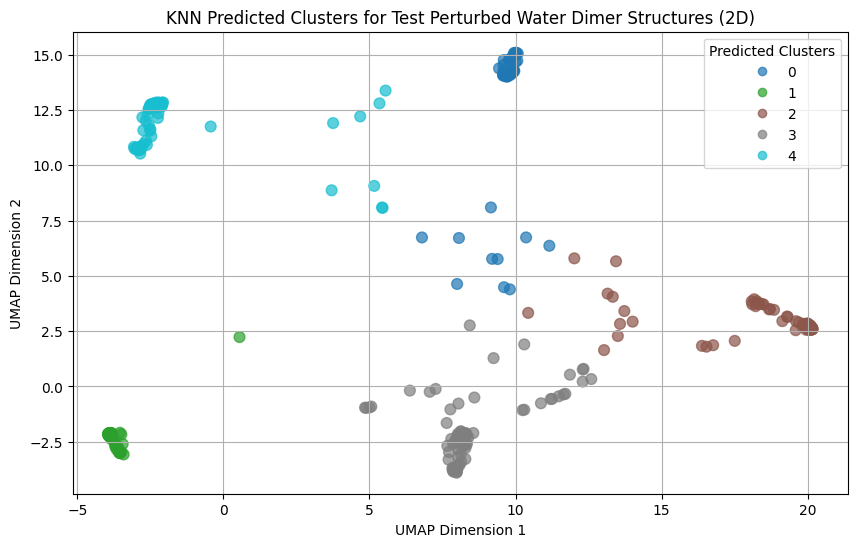

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=15)
# Train the Classifier on the original perturbed data and the cluster labels
knn_classifier.fit(umap_embedding, cluster_labels)
# Now we can predict the cluster labels for the test data
predicted_labels = knn_classifier.predict(test_embedding)
# Visualize the predicted labels
proba = knn_classifier.predict_proba(test_embedding)
confidences = np.max(proba, axis=1)
sizes = 10 + 50 * confidences  # Scale sizes based on confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(test_embedding[:, 0], test_embedding[:, 1], c=predicted_labels, cmap="tab10", alpha=0.7, s=sizes)
plt.title("KNN Predicted Clusters for Test Perturbed Water Dimer Structures (2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(*scatter.legend_elements(), title="Predicted Clusters")
plt.grid()
plt.show()

Next we try the SVM classifier using a radial basis function 

Number of low-confidence predictions: 24
Indices of low-confidence predictions: [ 34  44  51 193 200 222 243 261 276 282 299 304 305 346 405 408 411 437
 461 473 477 480 482 496]


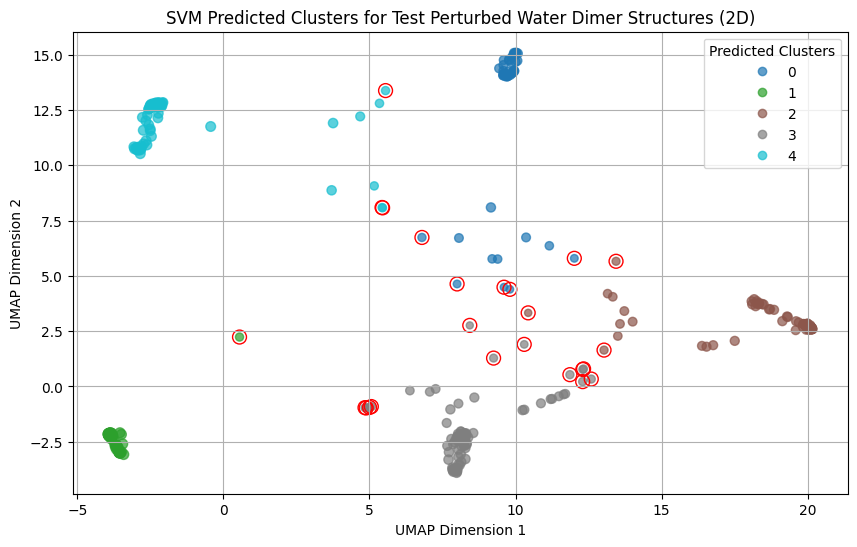

In [61]:
from sklearn.svm import SVC # Support Vector Classifier
svm_classifier = SVC(kernel="rbf", gamma="scale", probability=True, random_state=42)
# Train the SVM on the original perturbed data and the cluster labels
svm_classifier.fit(umap_embedding, cluster_labels)
# Now we can predict the cluster labels for the test data
svm_predicted_labels = svm_classifier.predict(test_embedding)
# Visualize the predicted labels
svm_proba = svm_classifier.predict_proba(test_embedding)


# Find points with the lowest probability for their predicted class (i.e., lowest confidence)
misclassified_indices = np.where(svm_proba.max(axis=1) < 0.5)[0]  # Threshold can be adjusted
print(f"Number of low-confidence predictions: {len(misclassified_indices)}")
print("Indices of low-confidence predictions:", misclassified_indices)


svm_confidences = np.max(svm_proba, axis=1)
svm_sizes = 10 + 50 * svm_confidences  # Scale sizes based on confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(test_embedding[:, 0], test_embedding[:, 1], c=svm_predicted_labels, cmap="tab10", alpha=0.7, s=svm_sizes)
# Highlight low-confidence predictions with a red edge
plt.scatter(test_embedding[misclassified_indices, 0], test_embedding[misclassified_indices, 1], facecolors='none', edgecolors='red', s=100, label='Low Confidence')

plt.title("SVM Predicted Clusters for Test Perturbed Water Dimer Structures (2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(*scatter.legend_elements(), title="Predicted Clusters")
plt.grid()
plt.show()

